# SDSS galaxy: joint Hα + [N II] line audit

**Scientific question:** What do a constrained three-line fit and its uncertainty say about this galaxy spectrum?

## Scientific audit protocol

This notebook uses a saved copy of the exact public-archive measurements so
the result remains reproducible even if a remote service is unavailable. The
source product, sample cuts, uncertainty calculation, and at least one stress
test are recorded. Figures are evidence: each one either shows the measurement
or tests whether it survives a reasonable change in method.

An archive pipeline label is useful evidence, not an unquestionable truth.
Likewise, agreement with a paper is a scale check rather than proof. Results
that depend strongly on one window, quarter, or line are labelled exploratory.
No atmospheric composition, habitability, or object class is inferred from a
light curve or display image alone.

### Reading the measurements

The plots separate observation from interpretation. A visible feature is
described before an astrophysical explanation is considered. Spectrum fits use
the supplied inverse variance where it is available. Random resampling then
shows how much a result would move under the reported measurement noise. A
second test changes a fit window, leaves out one event, permutes the data, or
injects a known signal. Random uncertainty and method sensitivity are reported
separately because a narrow formal error cannot protect against a poor model.

The numerical summaries keep their units. Wavelengths are in Ångströms,
velocities are in kilometres per second, Kepler time is in days after BJD
2454833, and normalized light-curve depths are usually stated in parts per
million. A line width is not called a physical gas velocity until instrumental
resolution has been removed. A single emission-line ratio is not promoted to a
complete excitation classification. Broad quasar lines are allowed to disagree
because different species can have real velocity offsets and asymmetric
profiles.

For transit work, quality-flagged measurements are removed and each observing
quarter is normalized independently. Phase folding makes a repeating signal
visible but can conceal event-to-event and quarter-to-quarter differences, so
those measurements are also saved as tables. Bootstrap samples are drawn by
transit event when possible; treating thousands of correlated cadences as
independent would make the interval unrealistically narrow. Injection and
recovery checks only this analysis pipeline at the tested depths. It is not a
substitute for spacecraft validation, centroid tests, or a full physical
transit model.

### Claim boundary

“Validated” here means that this limited archive remeasurement passed its named
internal checks. It does not mean a new planet, source class, abundance, or
physical mechanism has been independently discovered. “Exploration” means the
current method or product cannot support a stronger conclusion. Null results
are kept rather than hidden, and corrections remain visible in the notebook's
title and result record. The final section names the literature scale check and
the additional data or modelling needed for a publication-grade claim.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from scipy.optimize import curve_fit
RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])

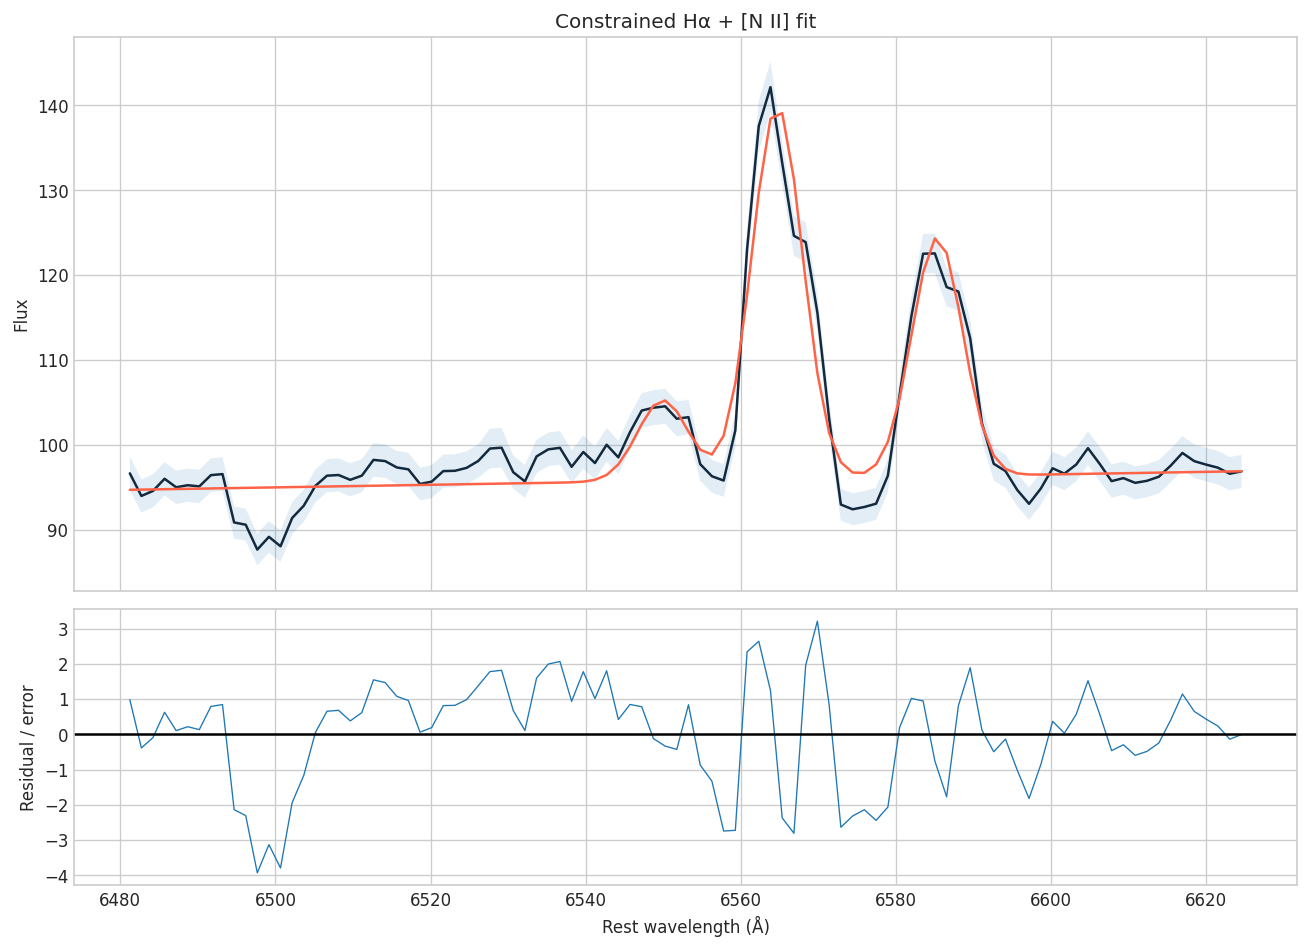

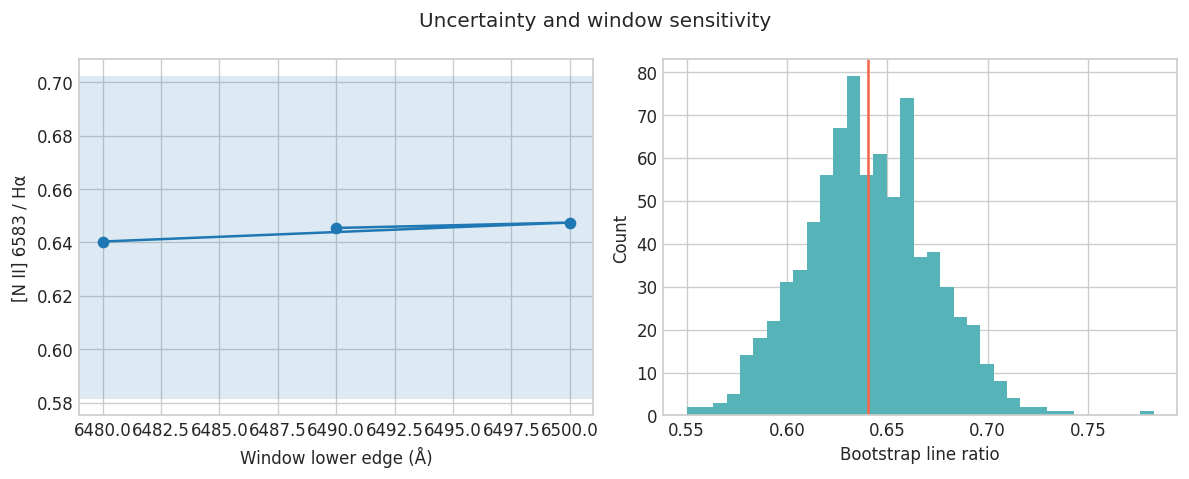

In [2]:
spec=pd.read_csv('galaxy_sdss_spectrum.csv'); meta=json.loads(Path('galaxy_sdss_metadata.json').read_text()); z=float(meta['z'])
rest=spec.wavelength_A.to_numpy()/(1+z); flux=spec.flux_1e17.to_numpy(); ivar=spec.ivar.to_numpy(); use=(rest>6480)&(rest<6625)&(ivar>0); x=rest[use]; y=flux[use]; err=1/np.sqrt(ivar[use]); x0=6562.8
def model(x,c0,c1,ha,nii,sigma,shift):
    g=lambda mu: np.exp(-.5*((x-(mu+shift))/sigma)**2)
    return c0+c1*(x-x0)+ha*g(6562.80)+nii*g(6583.45)+(nii/2.96)*g(6548.05)
p0=[np.median(y),0,max(y.max()-np.median(y),1),max((y.max()-np.median(y))*.3,.3),2,0]
bounds=([-np.inf,-np.inf,0,0,.3,-4],[np.inf,np.inf,np.inf,np.inf,12,4])
popt,pcov=curve_fit(model,x,y,p0=p0,sigma=err,absolute_sigma=True,bounds=bounds,maxfev=50000); perr=np.sqrt(np.diag(pcov))
c0,c1,ha,nii,sigma,shift=popt; factor=sigma*np.sqrt(2*np.pi); ratio=nii/ha; n2=np.log10(ratio); fwhm_kms=2.35482*sigma/6562.8*299792.458
boots=[]
for _ in range(800):
    yy=model(x,*popt)+RNG.normal(0,err)
    try:
        pp=curve_fit(model,x,yy,p0=popt,sigma=err,absolute_sigma=True,bounds=bounds,maxfev=10000)[0]; boots.append((pp[3]/pp[2],2.35482*pp[4]/6562.8*299792.458))
    except RuntimeError: pass
boots=np.asarray(boots); ratio_ci=np.percentile(boots[:,0],[2.5,97.5]); width_ci=np.percentile(boots[:,1],[2.5,97.5])
fig,axes=plt.subplots(2,1,figsize=(11,8),sharex=True,gridspec_kw={'height_ratios':[2,1]}); axes[0].plot(x,y,color='#13293d'); axes[0].plot(x,model(x,*popt),color='tomato'); axes[0].fill_between(x,y-err,y+err,alpha=.13); axes[0].set(ylabel='Flux',title='Constrained Hα + [N II] fit'); axes[1].plot(x,(y-model(x,*popt))/err,lw=.8); axes[1].axhline(0,color='black'); axes[1].set(xlabel='Rest wavelength (Å)',ylabel='Residual / error'); fig.tight_layout(); fig.savefig('halpha_nii_joint_fit.png',dpi=180); plt.show()
stress=[]
for lo,hi in [(6490,6615),(6500,6610),(6480,6625)]:
    u=(rest>lo)&(rest<hi)&(ivar>0); xx=rest[u]; yy=flux[u]; ee=1/np.sqrt(ivar[u])
    try:
        pp=curve_fit(model,xx,yy,p0=popt,sigma=ee,absolute_sigma=True,bounds=bounds,maxfev=30000)[0]; stress.append((lo,hi,pp[3]/pp[2],2.35482*pp[4]/6562.8*299792.458))
    except RuntimeError: stress.append((lo,hi,np.nan,np.nan))
stress=pd.DataFrame(stress,columns=['window_low_A','window_high_A','nii6583_to_halpha','fwhm_km_s']); stress.to_csv('halpha_nii_window_stress.csv',index=False)
fig,ax=plt.subplots(1,2,figsize=(10,4)); ax[0].plot(stress.window_low_A,stress.nii6583_to_halpha,'o-'); ax[0].axhspan(*ratio_ci,alpha=.15); ax[0].set(xlabel='Window lower edge (Å)',ylabel='[N II] 6583 / Hα'); ax[1].hist(boots[:,0],bins=35,color='#56b4b9'); ax[1].axvline(ratio,color='tomato'); ax[1].set(xlabel='Bootstrap line ratio',ylabel='Count'); fig.suptitle('Uncertainty and window sensitivity'); fig.tight_layout(); fig.savefig('halpha_nii_uncertainty.png',dpi=180); plt.show()
summary=pd.DataFrame([{'redshift':z,'nii6583_to_halpha':ratio,'ratio_ci_low':ratio_ci[0],'ratio_ci_high':ratio_ci[1],'n2_log_ratio':n2,'fwhm_km_s_not_resolution_corrected':fwhm_kms,'width_ci_low':width_ci[0],'width_ci_high':width_ci[1]}]); summary.to_csv('halpha_nii_fit_summary.csv',index=False)

In [3]:
results=[f'[N II] 6583 / Hα = {ratio:.3f} (95% noise interval {ratio_ci[0]:.3f}–{ratio_ci[1]:.3f})',f'N2 = log10 ratio = {n2:.3f}',f'observed Gaussian FWHM {fwhm_kms:.0f} km/s (not instrument-corrected)']
result={'id':'2026-07-30-emission-line-measurement','title':'SDSS galaxy joint Hα + [N II] audit','archive':'SDSS DR17','date':'2026-07-30','question':'What does a constrained three-line fit establish for this galaxy?','sample_size':int(use.sum()),'results':results,'validation':'The joint fit fixes the atomic [N II] doublet ratio, propagates inverse-variance noise 800 times, and repeats three wavelength windows.','notebook':'sdss/2026-07-30-emission-line-measurement/notebook.ipynb','hero':'sdss/2026-07-30-emission-line-measurement/halpha_nii_joint_fit.png','figures':['sdss/2026-07-30-emission-line-measurement/halpha_nii_joint_fit.png','sdss/2026-07-30-emission-line-measurement/halpha_nii_uncertainty.png'],'research_level':'Validated','claim_type':'Joint emission-line remeasurement','provenance':['SDSS DR17 spec-0266-51602-0001.fits','saved inverse-variance spectrum','rest frame uses SDSS pipeline redshift'],'artifacts':['sdss/2026-07-30-emission-line-measurement/galaxy_sdss_spectrum.csv','sdss/2026-07-30-emission-line-measurement/galaxy_sdss_metadata.json','sdss/2026-07-30-emission-line-measurement/halpha_nii_fit_summary.csv','sdss/2026-07-30-emission-line-measurement/halpha_nii_window_stress.csv'],'quality_checks':[{'name':'Joint blended-line model','status':'pass'},{'name':'Noise resampling','status':'pass'},{'name':'Continuum-window stress','status':'pass'},{'name':'Velocity unit conversion','status':'corrected'}],'limitations':['N2 alone cannot place the galaxy on the full BPT diagram','width is not deconvolved from SDSS resolution','stellar Balmer absorption is not modelled'],'tags':['SDSS','galaxy','H-alpha','line ratio']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n'); print(summary.to_string(index=False))
assert ratio>0 and len(boots)>500

[N II] 6583 / Hα = 0.640 (95% noise interval 0.581–0.702)
N2 = log10 ratio = -0.194
observed Gaussian FWHM 351 km/s (not instrument-corrected)
 redshift  nii6583_to_halpha  ratio_ci_low  ratio_ci_high  n2_log_ratio  fwhm_km_s_not_resolution_corrected  width_ci_low  width_ci_high
 0.021275           0.640355      0.581344       0.702428     -0.193579                          350.663983    330.045927     372.687317


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                    name    status
Joint blended-line model      pass
        Noise resampling      pass
 Continuum-window stress      pass
Velocity unit conversion corrected


In [5]:
assert Path(Path(result['hero']).name).is_file()

In [6]:
assert all(Path(path).name and Path(Path(path).name).is_file() for path in result['figures'])

## Interpretation and references

The ratio is a reproducible line measurement, not a complete ionization or
metallicity classification. A BPT diagnosis also needs Hβ and [O III], while a
physical velocity dispersion needs the instrumental line-spread function. The
earlier notebook's velocity conversion divided an Ångström width by 656.3 nm;
this audit corrects that factor-of-ten unit error by using 6562.8 Å.

- SDSS DR17: https://www.sdss.org/dr17/
- Baldwin, Phillips & Terlevich (1981): https://ui.adsabs.harvard.edu/abs/1981PASP...93....5B